# Bayesian Deep Learning

Bayesian Deep Learning is a field that tries to quantify uncertainty in artificial neural networks. In this approach, the weights of a model are treated as distributions instead of fixed values.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import torch
from torch.optim import Adam

from pai import BNNLA
from scoring import bnn_loss

mpl.rc_file_defaults()

## Toy Data

In [2]:
rng = np.random.default_rng(42)

x_numpy = np.linspace(0, 4 * np.pi, 200).reshape((200, 1))
x_short = np.concatenate([x_numpy[:20], x_numpy[40:80], x_numpy[100:120], x_numpy[150:]])
y_numpy = np.sin(x_short) + rng.normal(0, 0.2, size=x_short.shape)

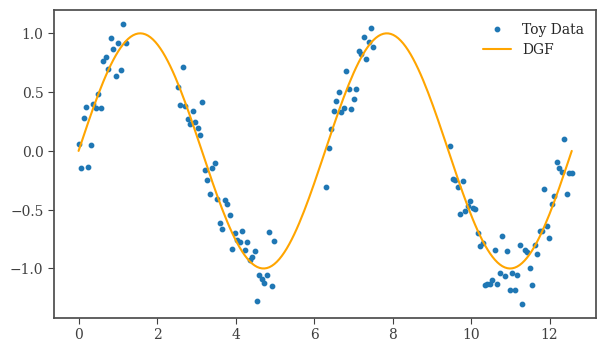

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(x_short, y_numpy, label="Toy Data", s=10)
ax.plot(x_numpy, np.sin(x_numpy), label="DGF", color="orange")
ax.legend()

plt.show()

## BNN with Laplace Approximation

A common problem with such Bayesian methods are intractable computations due to high computation costs. As such, it is common to use approximations. One possible approach are neural networks with Laplace Approximations, where the true posterior is approximated using a Gaussian distribution.

In [4]:
x = torch.from_numpy(x_short).to(torch.float32)
y = torch.from_numpy(y_numpy).to(torch.float32)

In [5]:
inv_prior = 0.009

bnn = BNNLA(x.shape[1], inv_prior)
optimizer = Adam(bnn.parameters(), lr=0.01, weight_decay=inv_prior)

for epoch in range(2_000):
    optimizer.zero_grad()

    y_mean, y_log_var = bnn(x)
    loss = bnn_loss(y_mean, y_log_var, y)
    loss.backward()

    optimizer.step()
    if epoch % 100 == 0:
        print(f"E{epoch}: Loss {loss.item():.4f}")

E0: Loss 0.3184
E100: Loss -0.6725
E200: Loss -0.6820
E300: Loss -0.7038
E400: Loss -0.7358
E500: Loss -0.8343
E600: Loss -1.0900
E700: Loss -1.1024
E800: Loss -1.1227
E900: Loss -1.1432
E1000: Loss -1.1575
E1100: Loss -1.1667
E1200: Loss -1.1810
E1300: Loss -1.1664
E1400: Loss -1.1812
E1500: Loss -1.3032
E1600: Loss -1.3326
E1700: Loss -1.3587
E1800: Loss -1.3662
E1900: Loss -1.3634


In [17]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

bnn.covariance(x_long)
y_pred, var_pred, total_var_pred = bnn.predict(x_long)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

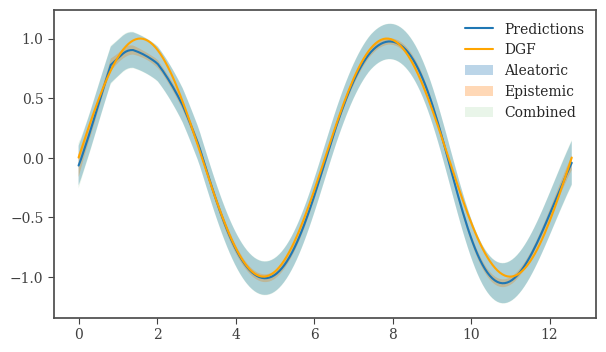

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, label="Aleatoric", alpha=0.3)
ax.fill_between(x_numpy.ravel(), y_pred - epistemic_std, y_pred + epistemic_std, label="Epistemic", alpha=0.3)
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, label="Combined", alpha=0.1)

ax.legend()

plt.show()

In [7]:
#